In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df["flower_name"]= df["target"].map({0: "setosa", 1: "versicolor", 2: "virginica"})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
df.shape

(150, 6)

In [15]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   flower_name        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [6]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
flower_name          0
dtype: int64

In [17]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool

In [7]:
x=df.drop(["target", "flower_name"],axis=1)
y=df["target"]

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, df["target"], test_size=0.2)
random_state=42

In [9]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    
    print(f"k = {k}: Accuracy = {acc:.4f}")
    

k = 1: Accuracy = 0.9667
k = 2: Accuracy = 0.9000
k = 3: Accuracy = 0.9667
k = 4: Accuracy = 0.9667
k = 5: Accuracy = 0.9667
k = 6: Accuracy = 0.9667
k = 7: Accuracy = 0.9667
k = 8: Accuracy = 0.9333
k = 9: Accuracy = 0.9333
k = 10: Accuracy = 0.9667
k = 11: Accuracy = 1.0000
k = 12: Accuracy = 0.9667
k = 13: Accuracy = 1.0000
k = 14: Accuracy = 0.9667
k = 15: Accuracy = 1.0000
k = 16: Accuracy = 0.9667
k = 17: Accuracy = 0.9667
k = 18: Accuracy = 0.9667
k = 19: Accuracy = 0.9667
k = 20: Accuracy = 0.9667


In [10]:
best_k = k_values[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)

print ("best k:", best_k)
print ("best accuracy:", best_accuracy)

best k: 11
best accuracy: 1.0


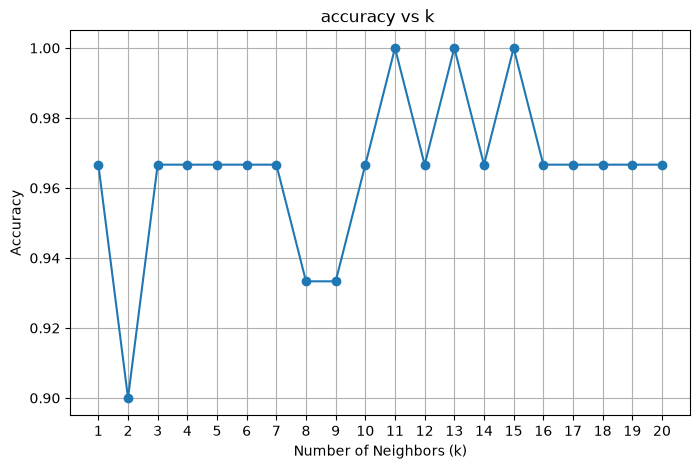

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.title("accuracy vs k ")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.xticks(k_values)d
plt.grid(True)
plt.show()